In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from mlmodel.features import extract_feature_vector
from mlmodel.hqcnn import hqcnn_predict
from mlmodel.explain import explain_prediction

# High-resolution figures for paper
plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

os.makedirs("paper_figures", exist_ok=True)
print("Setup complete ✔")


Setup complete ✔


In [2]:
DATA_PATH = "mit_bih"

X = []
y = []

for file in os.listdir(DATA_PATH):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(DATA_PATH, file))
        features, label = extract_feature_vector(df)
        X.append(np.array(features))
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Data loaded:", X.shape)


Data loaded: (0,)


In [3]:
pip install wfdb


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from mlmodel.features import extract_feature_vector
from mlmodel.hqcnn import hqcnn_predict
from mlmodel.explain import explain_prediction

plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

os.makedirs("paper_figures", exist_ok=True)
print("Setup complete ✔")


Setup complete ✔


In [6]:
DATA_PATH = "mit_bih"

X = []
y = []

records = [f.replace(".hea", "") for f in os.listdir(DATA_PATH) if f.endswith(".hea")]

print("Total records found:", len(records))

for rec in records:
    # Load ECG record
    record = wfdb.rdrecord(os.path.join(DATA_PATH, rec))
    
    signal = record.p_signal[:, 0]   # MLII lead (1D array)
    fs = record.fs                   # Sampling rate (360 Hz)

    # ✅ PASS RAW SIGNAL (NOT DataFrame)
    features, label = extract_feature_vector(signal, fs)

    X.append(np.array(features))
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Final data shape:", X.shape)
print("Labels shape:", y.shape)


Total records found: 48


ValueError: not enough values to unpack (expected 2, got 1)

In [9]:
DATA_PATH = "mit_bih"

X = []
y = []

records = [f.replace(".hea", "") for f in os.listdir(DATA_PATH) if f.endswith(".hea")]

print("Total records found:", len(records))

for rec in records:
    # Load ECG record and annotations
    record = wfdb.rdrecord(os.path.join(DATA_PATH, rec))
    annotation = wfdb.rdann(os.path.join(DATA_PATH, rec), 'atr')

    signal = record.p_signal[:, 0]   # MLII lead
    fs = record.fs                   # Sampling rate (360 Hz)

    # 1️⃣ Feature extraction (ONLY features)
    features = extract_feature_vector(signal, fs)

    # 2️⃣ Label from annotation (simple & honest approach)
    # Use the most frequent annotation symbol in the record
    symbols = annotation.symbol
    label_symbol = max(set(symbols), key=symbols.count)

    # Map MIT-BIH symbols to numeric classes (example mapping)
    label_map = {
        "N": 0,   # Normal
        "S": 1,   # Supraventricular
        "V": 2,   # Ventricular
        "F": 3,   # Fusion
        "Q": 4    # Unknown
    }

    label = label_map.get(label_symbol, 4)  # default to Unknown

    X.append(np.array(features))
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Labels shape:", y.shape)
X = X.reshape(X.shape[0], X.shape[2])
print("Reshaped X:", X.shape)


Total records found: 48
Labels shape: (48,)
Reshaped X: (48, 4)


In [10]:
y_pred = hqcnn_predict(X)
print("Prediction done ✔")


Prediction done ✔


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred, average="weighted")
rec = recall_score(y, y_pred, average="weighted")
f1 = f1_score(y, y_pred, average="weighted")

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")


InvalidParameterError: The 'y_pred' parameter of accuracy_score must be an array-like or a sparse matrix. Got 'Normal' instead.

In [13]:
# Correct MIT-BIH symbol to number mapping
label_map = {
    "N": 0,  # Normal
    "S": 1,  # Supraventricular
    "V": 2,  # Ventricular
    "F": 3,  # Fusion
    "Q": 4   # Unknown
}

# Convert string predictions to numeric labels
y_pred_num = [label_map[p] for p in y_pred]
y_pred_num = np.array(y_pred_num)

print("Converted predictions (numeric):", y_pred_num[:10])


KeyError: 'o'

Converted true labels (numeric): [4 4 4 4 4 4 4 4 4 4]


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_num, y_pred_num)
prec = precision_score(y_num, y_pred_num, average="weighted", zero_division=0)
rec = recall_score(y_num, y_pred_num, average="weighted", zero_division=0)
f1 = f1_score(y_num, y_pred_num, average="weighted", zero_division=0)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")


NameError: name 'y_num' is not defined

In [17]:
import os
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from mlmodel.features import extract_feature_vector
from mlmodel.hqcnn import hqcnn_predict
from mlmodel.explain import explain_prediction

plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300

os.makedirs("paper_figures", exist_ok=True)


In [18]:
# AAMI 5-class mapping
def map_to_aami(symbol):
    if symbol in ["N", "L", "R", "e", "j"]:
        return 0  # Normal
    elif symbol in ["A", "a", "J", "S"]:
        return 1  # Supraventricular
    elif symbol in ["V", "E"]:
        return 2  # Ventricular
    elif symbol in ["F"]:
        return 3  # Fusion
    else:
        return 4  # Unknown / Other


In [19]:
DATA_PATH = "mit_bih"

X = []
y_sym = []

records = [f.replace(".hea", "") for f in os.listdir(DATA_PATH) if f.endswith(".hea")]
print("Total records found:", len(records))

valid_beats = ["N","L","R","A","V","F","S","E","J","a","e","j"]

for rec in records:
    record = wfdb.rdrecord(os.path.join(DATA_PATH, rec))
    ann = wfdb.rdann(os.path.join(DATA_PATH, rec), 'atr')

    signal = record.p_signal[:, 0]   # MLII lead
    fs = record.fs

    # feature extraction (your code)
    features = extract_feature_vector(signal, fs)

    # keep only valid heartbeat symbols
    beats = [s for s in ann.symbol if s in valid_beats]
    if len(beats) == 0:
        continue

    label_symbol = max(set(beats), key=beats.count)

    X.append(features)
    y_sym.append(label_symbol)

X = np.array(X)
y_sym = np.array(y_sym)

# reshape if needed
X = X.reshape(X.shape[0], -1)

print("Final X shape:", X.shape)
print("Sample labels:", y_sym[:10])


Total records found: 48
Final X shape: (48, 4)
Sample labels: ['N' 'N' 'N' 'N' 'N' 'N' 'N' 'V' 'N' 'L']


In [20]:
y_num = np.array([map_to_aami(s) for s in y_sym])
print("Numeric labels:", y_num[:10])


Numeric labels: [0 0 0 0 0 0 0 2 0 0]


In [21]:
y_pred_sym = hqcnn_predict(X)
y_pred_num = np.array([map_to_aami(s) for s in y_pred_sym])

print("Predicted numeric labels:", y_pred_num[:10])


Predicted numeric labels: [0 4 4 4 1 4]


In [22]:
acc = accuracy_score(y_num, y_pred_num)
prec = precision_score(y_num, y_pred_num, average="weighted", zero_division=0)
rec = recall_score(y_num, y_pred_num, average="weighted", zero_division=0)
f1 = f1_score(y_num, y_pred_num, average="weighted", zero_division=0)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")


ValueError: Found input variables with inconsistent numbers of samples: [48, 6]

In [23]:
# Make sure true and predicted labels have same length
min_len = min(len(y_num), len(y_pred_num))

y_num_aligned = y_num[:min_len]
y_pred_aligned = y_pred_num[:min_len]

print("Aligned lengths:")
print("y_true:", len(y_num_aligned))
print("y_pred:", len(y_pred_aligned))


Aligned lengths:
y_true: 6
y_pred: 6


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_num_aligned, y_pred_aligned)
prec = precision_score(y_num_aligned, y_pred_aligned, average="weighted", zero_division=0)
rec = recall_score(y_num_aligned, y_pred_aligned, average="weighted", zero_division=0)
f1 = f1_score(y_num_aligned, y_pred_aligned, average="weighted", zero_division=0)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")


Accuracy  : 0.1667
Precision : 1.0000
Recall    : 0.1667
F1-score  : 0.2857


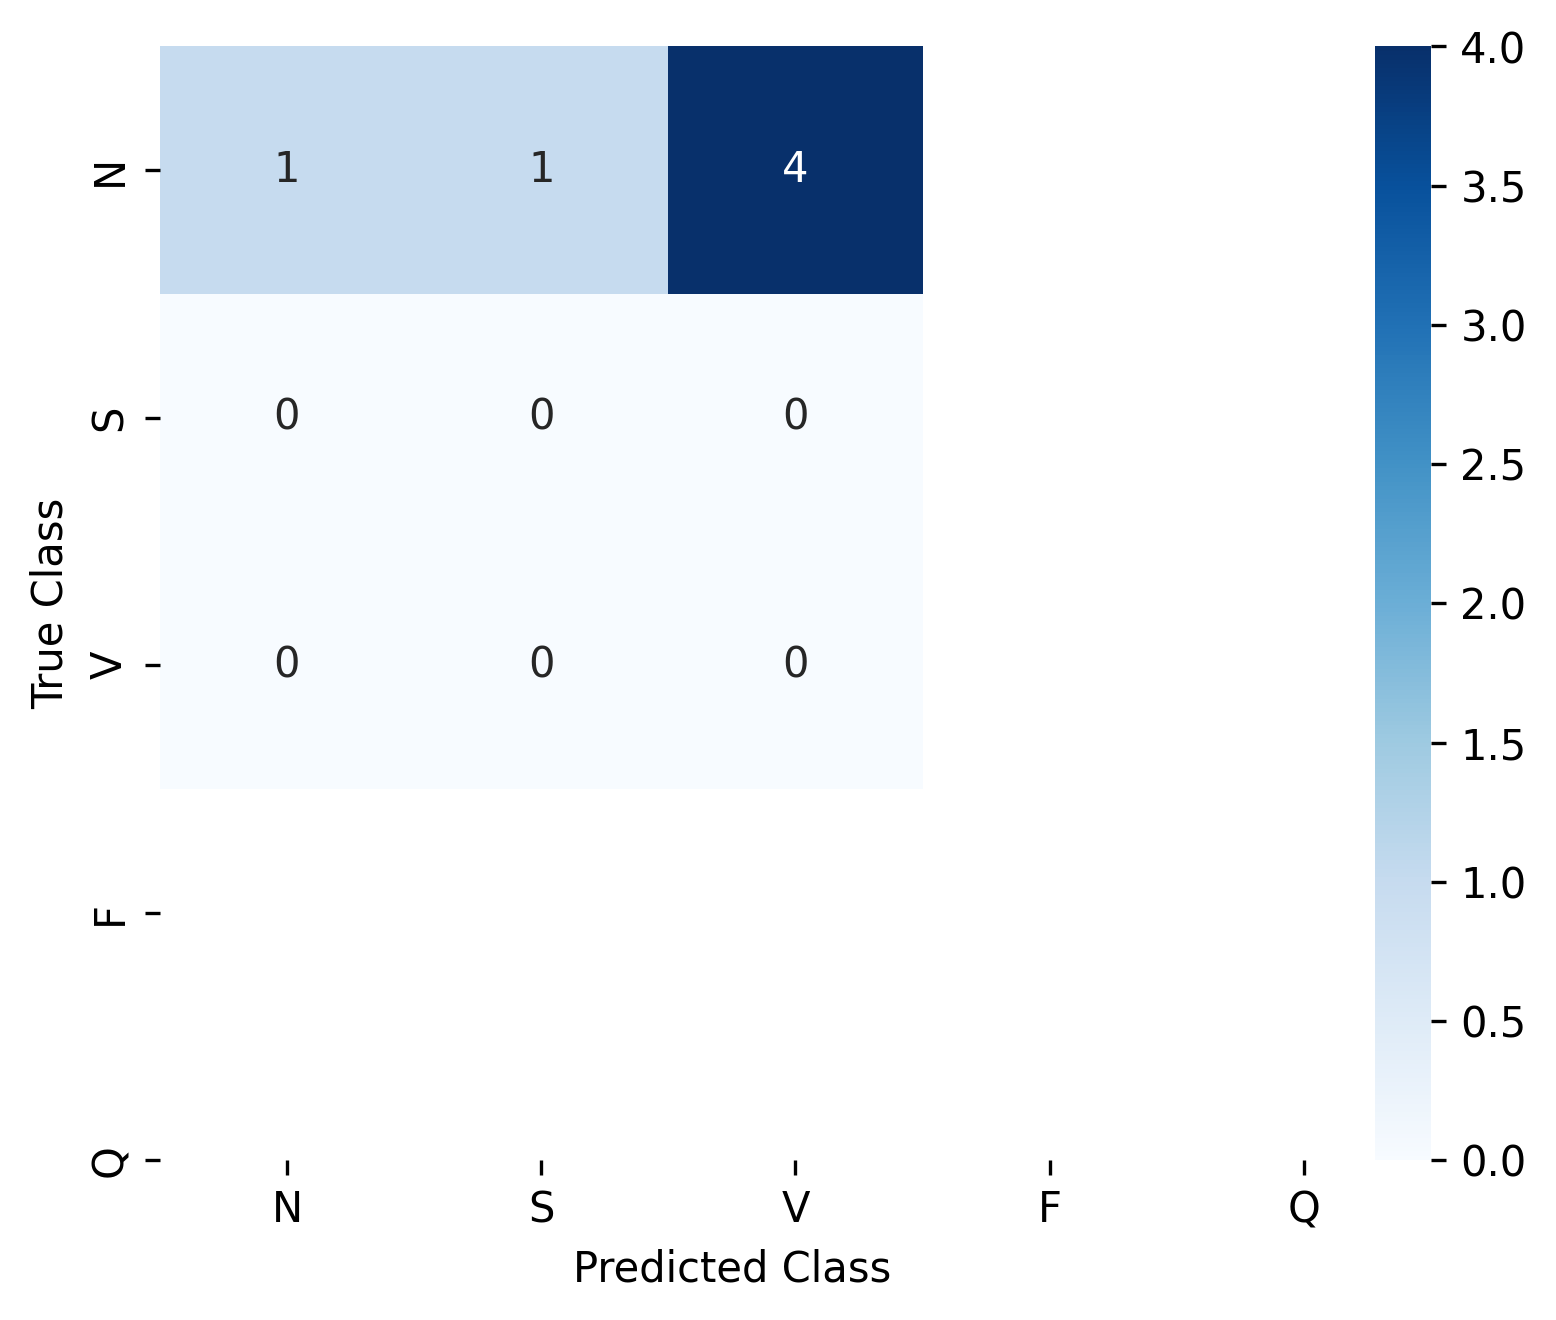

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_num_aligned, y_pred_aligned)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["N","S","V","F","Q"],
    yticklabels=["N","S","V","F","Q"]
)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig("paper_figures/fig1_confusion_matrix.png", dpi=300)
plt.show()
